## EXPLORADATORY DATA ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

In [3]:
file = "Halston_Reid_Case_Study.xlsx"
print(pd.ExcelFile(file).sheet_names)

df = pd.read_excel(file, sheet_name="Master data").dropna(how="all")
df["week_start_date"] = pd.to_datetime(df["week_start_date"])
df = df.sort_values("week_start_date").reset_index(drop=True)

print(df.shape)
df.head()

['Your project', 'Business brief', 'Glossary', 'Master data']
(130, 21)


,week_start_date,total_number_of_orders,online_transactions,online_revenue,store_transactions,store_revenue,total_revenue,Promotions,Product_Launches,EMAIL_SPEND,...,OOH_Spend,Print_ATL_Advertising_Spends,microsoft_spend,google_shopping_spend,google_search_spend,google_pmax_spend,meta_ads_prospecting_spend,meta_ads_retargeting_spend,tiktok_prospecting_spend,tiktok_retargeting_spend
0,2023-12-31,835,635,"220,893.99",200,"47,995.37","268,889.36",1,0,153,...,0,0,6.31,"3,759.13","1,023.25","3,031.71","1,538.68","4,458.06",0.00,0.00
1,2024-01-07,904,712,"240,288.79",192,"49,301.30","289,590.09",1,0,153,...,0,0,46.67,"2,932.33",909.00,"2,362.48","1,133.08","4,057.15",0.00,0.00
2,2024-01-14,706,521,"184,286.10",185,"51,219.44","235,505.54",0,0,153,...,0,0,51.43,442.74,"1,040.73",523.49,714.87,"2,153.91",0.00,0.00
3,2024-01-21,559,395,"156,014.26",164,"52,863.67","208,877.93",1,0,153,...,0,0,38.65,51.48,828.58,"1,435.27",20.81,715.92,0.00,0.00
4,2024-01-28,250,106,"64,768.32",144,"54,838.81","119,607.13",0,1,153,...,0,0,65.55,0.00,864.65,"1,257.86","2,014.14",574.75,0.00,0.00


In [4]:
# 1. Is every week present, with no gaps?
gaps = df["week_start_date"].diff().dt.days.value_counts()
print("Gaps between weeks (days):", gaps.to_dict())
print("Date range:", df.week_start_date.min().date(), "to", df.week_start_date.max().date())

# 2. Missing values
print("Missing values:", df.isna().sum().sum())

# 3. Do the totals add up?
rev_diff = (df.total_revenue - df.online_revenue - df.store_revenue).abs().max()
ord_diff = (df.total_number_of_orders - df.online_transactions - df.store_transactions).abs().max()
print(f"Max revenue mismatch: ${rev_diff:.4f}, max orders mismatch: {ord_diff}")

# 4. Negative spend?
spend_cols = [c for c in df.columns if "spend" in c.lower()]
print("Spend columns:", len(spend_cols))
print("Negative spend values:", (df[spend_cols] < 0).sum().sum())

# 5. Flag counts vs the brief (brief says 56 promo weeks, 33 launch weeks)
print("Promotion weeks:", df.Promotions.sum(), "| Launch weeks:", df.Product_Launches.sum())

Gaps between weeks (days): {7.0: 129}
Date range: 2023-12-31 to 2026-06-21
Missing values: 0
Max revenue mismatch: $0.0000, max orders mismatch: 0
Spend columns: 12
Negative spend values: 0
Promotion weeks: 56 | Launch weeks: 33


In [5]:
start = df["week_start_date"]
end = start + pd.Timedelta(days=6)

# A week belongs to the year it ENDS in, so the week of 31 Dec 2023 is 2024 week 1
df["report_year"] = end.dt.year
year_start = pd.to_datetime(df["report_year"].astype(str) + "-01-01")
mid = pd.concat([start + pd.Timedelta(days=3), year_start], axis=1).max(axis=1)
df["month_num"] = mid.dt.month
df["month_name"] = mid.dt.strftime("%b")
df["week_of_year"] = ((end - year_start).dt.days // 7 + 1).clip(1, 52)

# Derived KPIs
df["aov"] = df.total_revenue / df.total_number_of_orders
df["online_aov"] = df.online_revenue / df.online_transactions
df["store_aov"] = df.store_revenue / df.store_transactions
df["online_share"] = df.online_revenue / df.total_revenue
df["total_media_spend"] = df[spend_cols].sum(axis=1)

print(df.groupby("report_year").size())
df[["week_start_date", "report_year", "week_of_year", "month_name", "aov", "total_media_spend"]].head()

report_year
2024    52
2025    52
2026    26
dtype: int64


,week_start_date,report_year,week_of_year,month_name,aov,total_media_spend
0,2023-12-31,2024,1,Jan,322.02,"14,550.14"
1,2024-01-07,2024,2,Jan,320.34,"12,173.71"
2,2024-01-14,2024,3,Jan,333.58,"5,660.17"
3,2024-01-21,2024,4,Jan,373.66,"3,823.71"
4,2024-01-28,2024,5,Jan,478.43,"7,522.95"


In [6]:
yr = df.groupby("report_year").agg(
    revenue=("total_revenue", "sum"), media=("total_media_spend", "sum"),
    online_rev=("online_revenue", "sum"), online_tx=("online_transactions", "sum"),
    store_rev=("store_revenue", "sum"), store_tx=("store_transactions", "sum"))
yr["online_aov"] = yr.online_rev / yr.online_tx
yr["store_aov"] = yr.store_rev / yr.store_tx
yr["media_%_rev"] = 100 * yr.media / yr.revenue
display(yr[["online_aov", "store_aov", "media_%_rev"]])

# Brief says May-June is the biggest month. Months have 4 or 5 weeks, so check totals AND averages.
full = df[df.report_year < 2026]
print("Biggest month by TOTAL:", full.groupby(["report_year", "month_num"]).total_revenue.sum().groupby(level=0).idxmax().to_dict())
print("Biggest month by WEEKLY AVERAGE:", full.groupby(["report_year", "month_num"]).total_revenue.mean().groupby(level=0).idxmax().to_dict())

,online_aov,store_aov,media_%_rev
report_year,,,
2024,470.94,418.11,4.77
2025,507.41,423.19,3.46
2026,573.36,489.63,4.11


Biggest month by TOTAL: {2024: (2024, 7), 2025: (2025, 7)}
Biggest month by WEEKLY AVERAGE: {2024: (2024, 6), 2025: (2025, 6)}


In [7]:
# 2026 is only half a year, so compare weeks 1-25 of each year
h1 = df[df.week_of_year <= 25].groupby("report_year").agg(
    revenue=("total_revenue", "sum"), orders=("total_number_of_orders", "sum"))
h1["aov"] = h1.revenue / h1.orders
display(h1)
print("YoY % change:")
display((100 * h1.pct_change()).dropna())

# Revenue = Orders x AOV, so log growth splits exactly into volume + basket value
for a, b in [(2024, 2025), (2025, 2026)]:
    d_rev = np.log(h1.loc[b, "revenue"] / h1.loc[a, "revenue"])
    d_ord = np.log(h1.loc[b, "orders"] / h1.loc[a, "orders"])
    print(f"H1 {b} vs {a}: {100*d_ord/d_rev:.0f}% of growth from more orders, {100*(1-d_ord/d_rev):.0f}% from higher AOV")

,revenue,orders,aov
report_year,,,
2024,"6,230,875.39",13964,446.21
2025,"7,719,260.96",16202,476.44
2026,"9,917,441.00",18614,532.79


YoY % change:


,revenue,orders,aov
report_year,,,
2025,23.89,16.03,6.77
2026,28.48,14.89,11.83


H1 2025 vs 2024: 69% of growth from more orders, 31% from higher AOV
H1 2026 vs 2025: 55% of growth from more orders, 45% from higher AOV


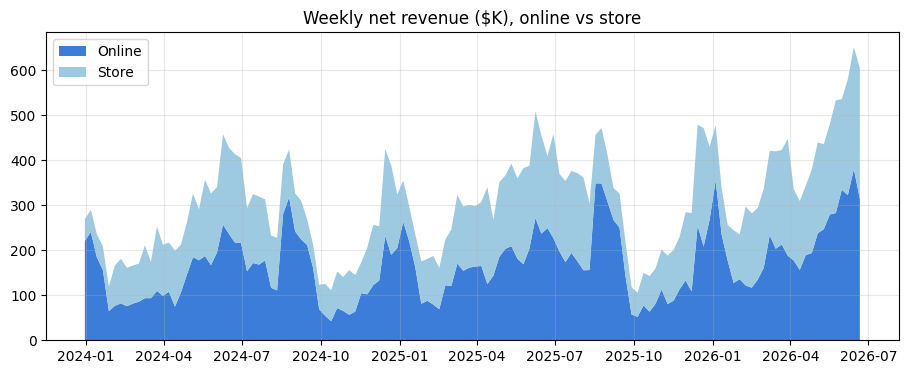

In [8]:
fig, ax = plt.subplots()
ax.stackplot(df.week_start_date, df.online_revenue / 1e3, df.store_revenue / 1e3,
             labels=["Online", "Store"], colors=["#3b7dd8", "#9ecae1"])
ax.set_title("Weekly net revenue ($K), online vs store")
ax.legend(loc="upper left")
plt.show()

Growth is strong (+24% and +28% H1 YoY) and increasingly comes from higher AOV (45% of H1 2026 growth vs 31% a year earlier), consistent with the brief's price increases and richer full-price mix.

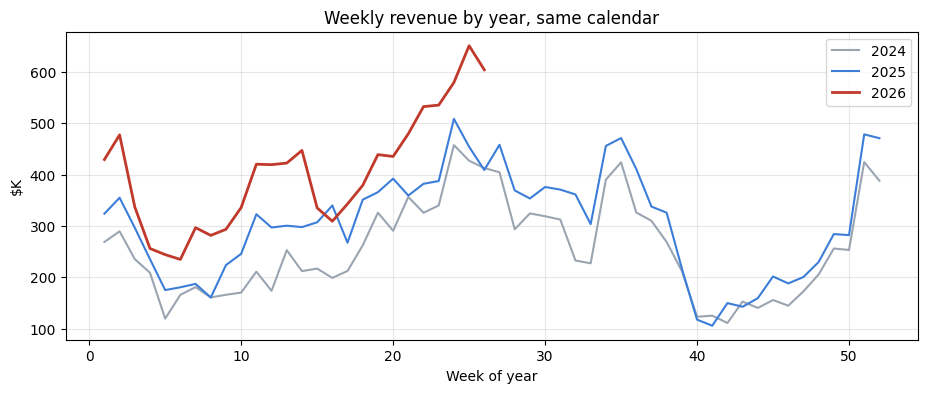

In [9]:
colors = {2024: "#9aa5b1", 2025: "#3b7dd8", 2026: "#c0392b"}
fig, ax = plt.subplots()
for y, g in df.groupby("report_year"):
    ax.plot(g.week_of_year, g.total_revenue / 1e3, color=colors[y], label=str(y), lw=2 if y == 2026 else 1.5)
ax.set_xlabel("Week of year"); ax.set_ylabel("$K")
ax.set_title("Weekly revenue by year, same calendar")
ax.legend()
plt.show()

report_year,2024,2025,2026,YoY 2025 %
month_num,,,,
Jan,224.50,277.20,348.90,23.50
Feb,168.40,188.10,276.70,11.70
Mar,202.00,291.60,399.60,44.30
Apr,210.10,312.80,362.80,48.90
May,312.30,374.90,471.70,20.10
Jun,409.40,440.00,592.70,7.50
Jul,330.90,385.60,NaN,16.50
Aug,318.60,398.10,NaN,25.00
Sep,279.30,323.10,NaN,15.70


Peak-to-trough (Jun vs Oct 2025): 3.3x


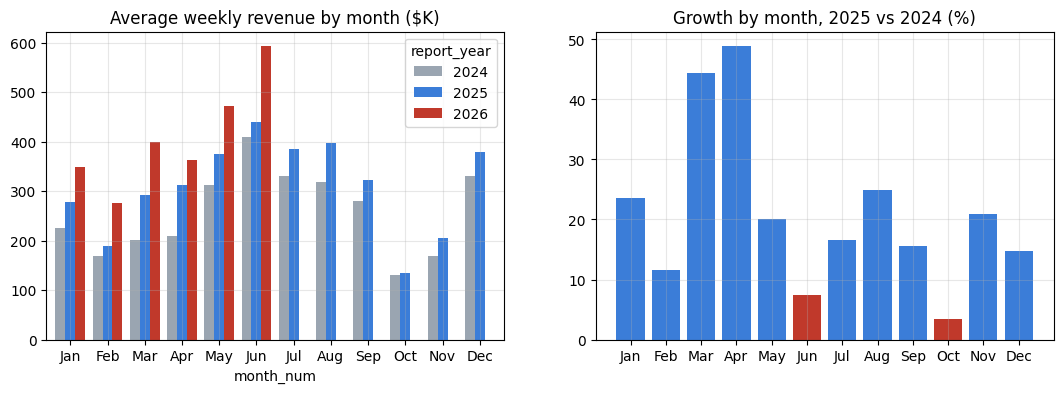

In [10]:
m_avg = df.groupby(["month_num", "report_year"]).total_revenue.mean().unstack() / 1e3
m_avg.index = pd.to_datetime(m_avg.index, format="%m").strftime("%b")
m_avg["YoY 2025 %"] = 100 * (m_avg[2025] / m_avg[2024] - 1)
display(m_avg.round(1))
print(f"Peak-to-trough (Jun vs Oct 2025): {m_avg.loc['Jun', 2025] / m_avg.loc['Oct', 2025]:.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
m_avg[[2024, 2025, 2026]].plot.bar(ax=axes[0], color=[colors[y] for y in [2024, 2025, 2026]], width=0.8)
axes[0].set_title("Average weekly revenue by month ($K)")
axes[1].bar(m_avg.index, m_avg["YoY 2025 %"],
            color=["#c0392b" if v < 10 else "#3b7dd8" for v in m_avg["YoY 2025 %"]])
axes[1].set_title("Growth by month, 2025 vs 2024 (%)")
for ax in axes: ax.tick_params(axis="x", rotation=0)
plt.show()

In [11]:
q = df.set_index("week_start_date").resample("QS")[["online_revenue", "online_transactions",
                                                  "store_revenue", "store_transactions", "total_revenue"]].sum()
q["Online AOV"] = q.online_revenue / q.online_transactions
q["Store AOV"] = q.store_revenue / q.store_transactions
q["Online share %"] = 100 * q.online_revenue / q.total_revenue
q = q[q.index >= "2024-01-01"]
display(q[["Online AOV", "Store AOV", "Online share %"]].round(1))

share_m = df.groupby("month_num").online_share.mean().mul(100).round(1)
share_m.index = pd.to_datetime(share_m.index, format="%m").strftime("%b")
print("Online share of revenue by month (%):")
print(share_m.to_string())

,Online AOV,Store AOV,Online share %
week_start_date,,,
2024-01-01,455.70,396.20,56.60
2024-04-01,515.50,426.00,53.70
2024-07-01,430.00,377.50,63.80
2024-10-01,513.40,434.20,50.50
2025-01-01,522.00,415.30,56.60
2025-04-01,556.10,448.90,51.50
2025-07-01,458.70,398.50,62.00
2025-10-01,508.90,453.10,49.40
2026-01-01,543.50,491.10,53.70


Online share of revenue by month (%):
month_num
Jan   68.40
Feb   46.80
Mar   50.10
Apr   49.10
May   54.00
Jun   55.70
Jul   51.90
Aug   61.30
Sep   74.50
Oct   47.60
Nov   47.80
Dec   48.30


In [12]:
naive = df.groupby("Promotions")[["total_revenue", "aov"]].mean()
naive.index = ["Non-promo week", "Promo week"]
display(naive)
print(f"Naive revenue difference: {100 * (naive.total_revenue.iloc[1] / naive.total_revenue.iloc[0] - 1):+.1f}%")

,total_revenue,aov
Non-promo week,"273,096.34",502.34
Promo week,"350,166.64",464.61


Naive revenue difference: +28.2%


,promo weeks,revenue diff %,AOV diff %
month_num,,,
Jan,7,4.70,-10.80
Feb,1,-25.50,-22.40
Mar,7,2.30,-5.00
Apr,4,-17.60,-9.00
May,6,3.70,0.60
Jun,8,34.00,8.90
Jul,4,-13.90,-4.90
Aug,4,54.80,-11.70
Sep,7,-8.80,4.10


Weighted revenue difference: +11.1%
Weighted AOV difference:     -3.2%
Months where promo AOV is lower: 64%


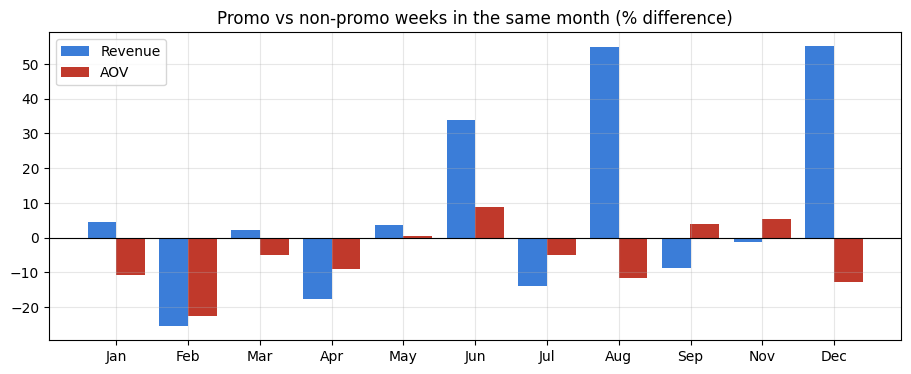

In [13]:
g = df.groupby(["month_num", "Promotions"]).agg(rev=("total_revenue", "mean"),
                                                aov=("aov", "mean"),
                                                n=("total_revenue", "size")).unstack()
g = g[g["n"][1].notna() & g["n"][0].notna()]
w = g["n"][1]
rev_diff = g["rev"][1] / g["rev"][0] - 1
aov_diff = g["aov"][1] / g["aov"][0] - 1

within = pd.DataFrame({"promo weeks": w.astype(int),
                       "revenue diff %": 100 * rev_diff, "AOV diff %": 100 * aov_diff})
within.index = pd.to_datetime(within.index, format="%m").strftime("%b")
display(within.round(1))
print(f"Weighted revenue difference: {100 * np.average(rev_diff, weights=w):+.1f}%")
print(f"Weighted AOV difference:     {100 * np.average(aov_diff, weights=w):+.1f}%")
print(f"Months where promo AOV is lower: {(aov_diff < 0).mean():.0%}")

fig, ax = plt.subplots()
x = np.arange(len(within))
ax.bar(x - 0.2, within["revenue diff %"], 0.4, label="Revenue", color="#3b7dd8")
ax.bar(x + 0.2, within["AOV diff %"], 0.4, label="AOV", color="#c0392b")
ax.set_xticks(x, within.index); ax.axhline(0, color="k", lw=0.8)
ax.set_title("Promo vs non-promo weeks in the same month (% difference)")
ax.legend()
plt.show()

In [14]:
print("Promotions vs launches (weeks):")
display(pd.crosstab(df.Promotions, df.Product_Launches, margins=True))

base = df[df.Product_Launches == 0].groupby("month_num").total_revenue.mean()
df["rev_vs_month_base"] = df.total_revenue / df.month_num.map(base) - 1
launch_idx = df.index[df.Product_Launches == 1]
for k in range(4):
    idx = [i + k for i in launch_idx if i + k < len(df)]
    print(f"{k} weeks after launch: {100 * df.loc[idx, 'rev_vs_month_base'].mean():+.1f}% vs same-month baseline")

Promotions vs launches (weeks):


Product_Launches,0,1,All
Promotions,,,
0,49,25,74
1,48,8,56
All,97,33,130


0 weeks after launch: -8.7% vs same-month baseline
1 weeks after launch: -4.9% vs same-month baseline
2 weeks after launch: -4.5% vs same-month baseline
3 weeks after launch: -1.1% vs same-month baseline


**Observation.** The naive +28% promo uplift is mostly timing: within the same month it falls to about +11%, and it is concentrated in months where the promotion *is* the calendar event (Memorial Day, Labor Day, Black Friday), so promotion and season cannot be separated. AOV is about 3% lower in promo weeks and lower in roughly two-thirds of months. For a full-price luxury brand, promotions buy uncertain extra revenue at a visible cost in basket value.

Launches rarely overlap promotions (8 of 33 weeks), consistent with a full-price strategy. Launch weeks run about 9% below their same-month baseline and recover over the next three weeks, so there is no immediate volume spike; the effect may show in AOV and mix rather than order counts.

In [15]:
channel_name = {
    "EMAIL_SPEND": "Email", "Direct_mail_spend": "Direct mail", "OOH_Spend": "OOH",
    "Print_ATL_Advertising_Spends": "Print", "microsoft_spend": "Microsoft Ads",
    "google_shopping_spend": "Google Shopping", "google_search_spend": "Google Search",
    "google_pmax_spend": "Google PMax", "meta_ads_prospecting_spend": "Meta Prospecting",
    "meta_ads_retargeting_spend": "Meta Retargeting",
    "tiktok_prospecting_spend": "TikTok Prospecting", "tiktok_retargeting_spend": "TikTok Retargeting"}
channel_family = {
    "EMAIL_SPEND": "Owned / CRM", "Direct_mail_spend": "Owned / CRM",
    "OOH_Spend": "Brand / Offline", "Print_ATL_Advertising_Spends": "Brand / Offline",
    "microsoft_spend": "Paid search", "google_shopping_spend": "Paid search",
    "google_search_spend": "Paid search", "google_pmax_spend": "Paid search",
    "meta_ads_prospecting_spend": "Paid social", "meta_ads_retargeting_spend": "Paid social",
    "tiktok_prospecting_spend": "Paid social", "tiktok_retargeting_spend": "Paid social"}

spend_year = df.groupby("report_year")[spend_cols].sum().T.rename(index=channel_name)
spend_year["Total"] = spend_year.sum(axis=1)
spend_year = spend_year.sort_values("Total", ascending=False)
display((spend_year / 1e3).round(1))

media = df.groupby("report_year").agg(media=("total_media_spend", "sum"), revenue=("total_revenue", "sum"))
media["media % of revenue"] = 100 * media.media / media.revenue
display(media)

report_year,2024,2025,2026,Total
Direct mail,133.00,165.80,128.50,427.30
Google PMax,129.00,47.80,16.80,193.60
Google Search,72.70,68.40,51.70,192.80
Meta Prospecting,94.10,50.30,39.50,183.90
Print,47.80,50.10,84.10,182.10
Google Shopping,16.00,66.20,73.00,155.20
Meta Retargeting,64.00,50.10,13.10,127.20
OOH,60.00,0.00,0.00,60.00
TikTok Prospecting,0.60,20.70,12.60,33.90
Microsoft Ads,9.50,16.80,4.20,30.50


,media,revenue,media % of revenue
report_year,,,
2024,"636,311.58","13,343,629.18",4.77
2025,"551,770.40","15,953,086.02",3.46
2026,"431,927.05","10,521,745.78",4.11


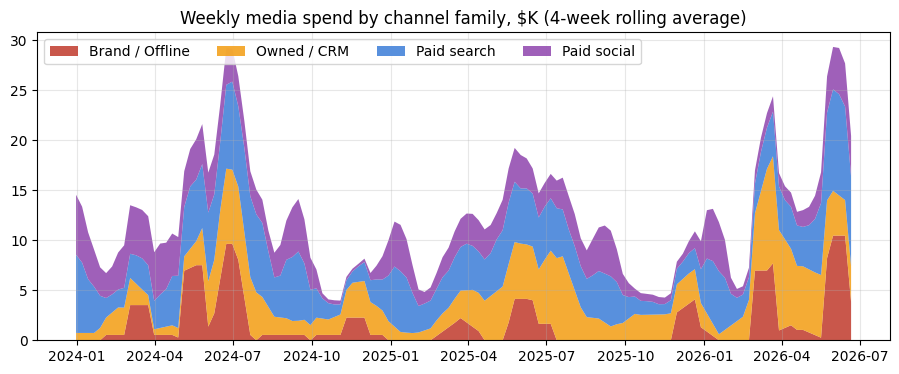

In [16]:
fam = df.set_index("week_start_date")[spend_cols].T.groupby(channel_family).sum().T
fam_4w = fam.rolling(4, min_periods=1).mean() / 1e3

fig, ax = plt.subplots()
ax.stackplot(fam_4w.index, fam_4w.T.values, labels=fam_4w.columns,
             colors=["#c0392b", "#f39c12", "#3b7dd8", "#8e44ad"], alpha=0.85)
ax.set_title("Weekly media spend by channel family, $K (4-week rolling average)")
ax.legend(loc="upper left", ncol=4)
plt.show()

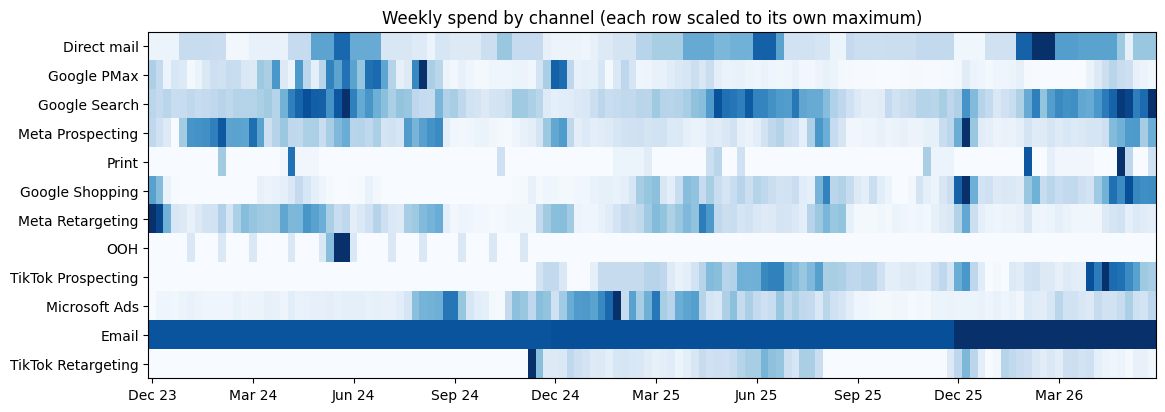

In [17]:
wide = df.set_index("week_start_date")[spend_cols].rename(columns=channel_name)
wide = wide[spend_year.index]                       # biggest channel first
norm = (wide / wide.max()).T

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.imshow(norm.values, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_yticks(range(len(norm)), norm.index)
ticks = list(range(0, norm.shape[1], 13))
ax.set_xticks(ticks, [norm.columns[i].strftime("%b %y") for i in ticks])
ax.grid(False)
ax.set_title("Weekly spend by channel (each row scaled to its own maximum)")
plt.show()

**Observation.** Marketing is lean and brand-led: media is only 3–5% of revenue, and direct mail is the largest single line. The heatmap shows the structural changes in the brief: Google Shopping paused twice in 2024 and then scaled up to the largest paid channel; PMax cut from $129K to $48K; OOH only in 2024; TikTok switched on in December 2024; print in short bursts around launches.

Notably, 2025 revenue grew about 20% while media spend fell about 13%. Either demand is increasingly organic (brand, CRM, price and mix) or the shift from PMax and paid social into Shopping was more efficient. The data alone cannot tell these apart.

## Step 6 — Marketing vs sales: observed relationships
Spend and revenue both rise in peak season and trend upward, so raw correlations are inflated. We remove month-of-year seasonality and a linear trend from revenue (a regression on month dummies plus a time index), then correlate spend with what is left, at lags of 0–3 weeks. This is still correlation, not causation: it shows where to test, not what each channel is worth.

In [20]:
X = pd.get_dummies(df.month_num, prefix="m", drop_first=True).astype(float)
X["trend"] = np.arange(len(df))
X["const"] = 1.0

def residual(y):
    beta = np.linalg.lstsq(X.values, y.values, rcond=None)[0]
    return pd.Series(y.values - X.values @ beta, index=y.index)

targets = {"online": df.online_revenue, "store": df.store_revenue}
resid = {k: residual(v) for k, v in targets.items()}

rows = []
for col in [c for c in spend_cols if c != "EMAIL_SPEND"]:     # email is a flat fee
    for t in ["online", "store"]:
        lag_r = {k: df[col].shift(k).corr(resid[t]) for k in range(4)}
        best = max(lag_r, key=lag_r.get)
        rows.append({"channel": channel_name[col], "revenue": t,
                     "raw corr": df[col].corr(targets[t]),
                     "adjusted corr (lag 0)": lag_r[0],
                     "best adjusted corr": lag_r[best], "best lag (wks)": best})
corr = pd.DataFrame(rows).sort_values("best adjusted corr", ascending=False).reset_index(drop=True)
display(corr.round(2))

,channel,revenue,raw corr,adjusted corr (lag 0),best adjusted corr,best lag (wks)
0,Meta Prospecting,online,0.38,0.37,0.37,0
1,Meta Retargeting,online,0.37,0.35,0.35,0
2,Google Shopping,online,0.63,0.32,0.32,0
3,Print,store,0.24,0.03,0.22,3
4,Google PMax,online,0.21,0.20,0.20,0
5,Direct mail,store,0.60,0.13,0.18,2
6,Print,online,0.10,-0.02,0.13,3
7,OOH,store,0.11,0.09,0.13,1
8,TikTok Prospecting,online,0.49,0.12,0.12,0
9,Meta Prospecting,store,0.05,0.12,0.12,0


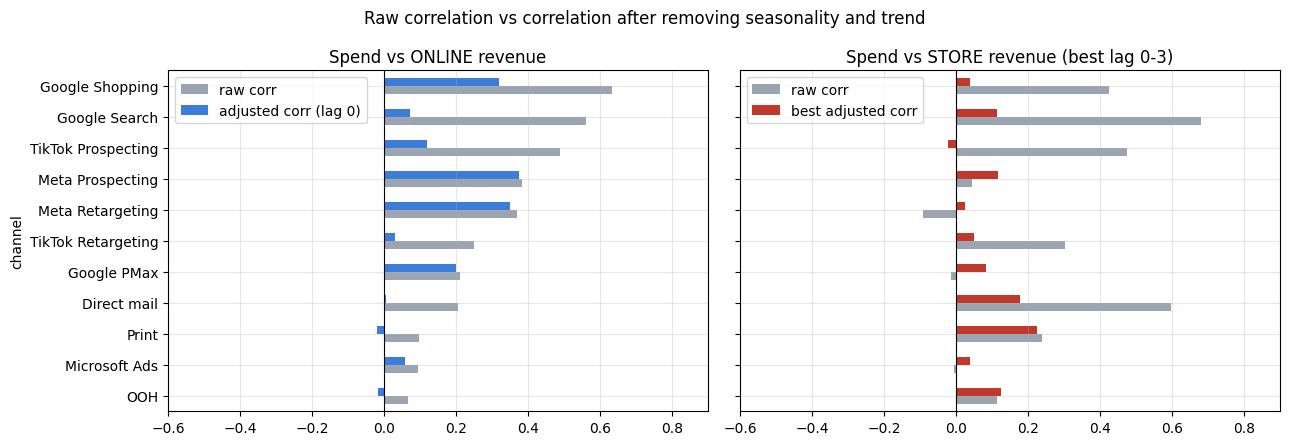

In [21]:
on = corr[corr.revenue == "online"].set_index("channel")[["raw corr", "adjusted corr (lag 0)"]].sort_values("raw corr")
st = corr[corr.revenue == "store"].set_index("channel")[["raw corr", "best adjusted corr"]].loc[on.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
on.plot.barh(ax=axes[0], color=["#9aa5b1", "#3b7dd8"]); axes[0].set_title("Spend vs ONLINE revenue")
st.plot.barh(ax=axes[1], color=["#9aa5b1", "#c0392b"]); axes[1].set_title("Spend vs STORE revenue (best lag 0-3)")
for ax in axes:
    ax.axvline(0, color="k", lw=0.8); ax.set_xlim(-0.6, 0.9)
fig.suptitle("Raw correlation vs correlation after removing seasonality and trend")
plt.tight_layout()
plt.show()

,before pause: 2024 vs 2025 %,during pause: 2024 vs 2025 %
Online orders,12.80,-24.00
Store orders,-46.80,-17.30


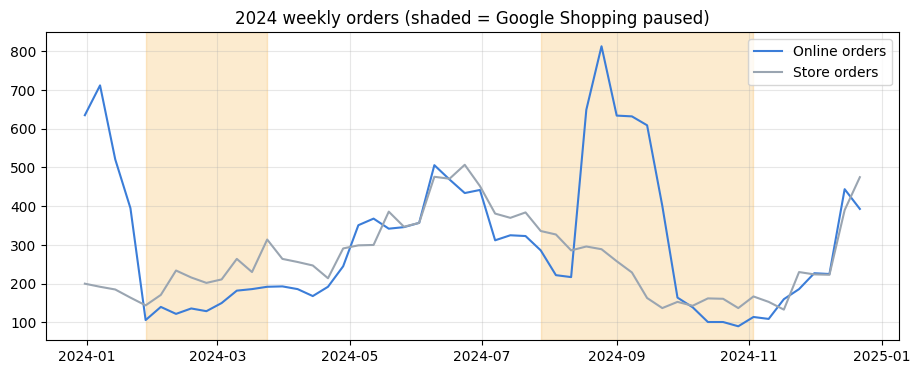

In [22]:
pause = df[(df.week_start_date >= "2024-01-28") & (df.week_start_date <= "2024-03-24")].week_of_year
pre = range(1, pause.min())

def yoy(weeks, col):
    a = df[(df.report_year == 2024) & df.week_of_year.isin(weeks)][col].sum()
    b = df[(df.report_year == 2025) & df.week_of_year.isin(weeks)][col].sum()
    return 100 * (a / b - 1)

event = pd.DataFrame({
    "before pause: 2024 vs 2025 %": [yoy(pre, "online_transactions"), yoy(pre, "store_transactions")],
    "during pause: 2024 vs 2025 %": [yoy(pause, "online_transactions"), yoy(pause, "store_transactions")]},
    index=["Online orders", "Store orders"])
display(event.round(1))

sub = df[df.report_year == 2024]
fig, ax = plt.subplots()
ax.plot(sub.week_start_date, sub.online_transactions, color="#3b7dd8", label="Online orders")
ax.plot(sub.week_start_date, sub.store_transactions, color="#9aa5b1", label="Store orders")
for s, e in [("2024-01-28", "2024-03-24"), ("2024-07-28", "2024-11-03")]:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color="#f39c12", alpha=0.2)
ax.set_title("2024 weekly orders (shaded = Google Shopping paused)")
ax.legend()
plt.show()